# Sample corpus from source data

In [1]:
import pandas as pd
import seaborn as sns
import glob
import json
import os

In [2]:
fin_file_paths = glob.glob("../data/fin_Latn/*token_counts.jsonl")
swe_file_paths = glob.glob("../data/swe_Latn/*token_counts.jsonl")

In [3]:
def read_data(file_paths):
    d = []
    for f_p in file_paths:
        with open(f_p) as f:
            for l in f:
                json_line = json.loads(l)
                d.append(json_line)
    return d

fin_d = read_data(fin_file_paths)
swe_d = read_data(swe_file_paths)

In [4]:
fin_df = pd.DataFrame(data=fin_d)

In [5]:
fin_df = fin_df.set_index('id')


In [4]:
def assign_bin(t):
    if 1000 <= t < 3000:
        return "1k-3k"
    elif 3000 <= t < 10000:
        return "3k-10k"
    elif 10000 <= t < 128000:
        return "10k-128k"
    elif t >= 128000:
        return ">=128000"
    else:
        return "<1k"

In [7]:
fin_df["bin"] = fin_df["tokens"].apply(assign_bin)
fin_df['bin'].value_counts()

bin
<1k         3012173
1k-3k       1746424
3k-10k       539098
10k-128k      53911
>=128000         92
Name: count, dtype: int64

<Axes: xlabel='bin', ylabel='Count'>

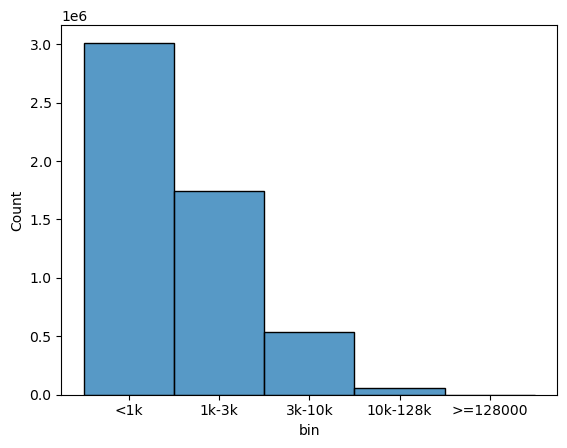

In [8]:
sns.histplot(data=fin_df, x="bin")

In [5]:
seed = 66
bins_to_use = ["1k-3k", "3k-10k","10k-128k",">=128000"]
# Define ratios per bin (must sum to 1.0)
n_per_bin = {
    "1k-3k": 5000,
    "3k-10k": 44930,
    "10k-128k": 50000,
    ">=128000": 70,
}


In [10]:
parts = []
for b, n in n_per_bin.items():
    g = fin_df[fin_df["bin"] == b]
    parts.append(g.sample(n=n, random_state=seed))

fin_sampled = pd.concat(parts)
fin_sampled = fin_sampled.sample(frac=1, random_state=seed).reset_index()

In [11]:
fin_sampled

,id,tokens,chars,bin
0,2600a9784f5dedbf2a4a4eb632fa3256,4157,31772,3k-10k
1,d4d1d3317b30d037eac56d0659d467f0,20999,147977,10k-128k
2,c9727f450eb915126bd4f707c742cf52,18998,129113,10k-128k
3,59c29c9a3687ffb2558b6517b418a480,6244,44834,3k-10k
4,36e275a5c4b1e51c508867aa780d55a6,3463,20357,3k-10k
...,...,...,...,...
99995,d59947a540e324d689dc069a4a89d5da,125861,807673,10k-128k
99996,6cd761b79086f5340ed5728d0bd4ea25,10355,63666,10k-128k
99997,2f7d83b1b8e6df7a10607548839e6e3b,5422,39198,3k-10k
99998,4f57b4409c45248c00a5b66b7835b9bb,5889,40892,3k-10k


In [12]:
fin_sampled.describe()

,tokens,chars
count,100000.000000,1.000000e+05
mean,10782.985120,7.611380e+04
std,10755.569265,7.610661e+04
min,1000.000000,5.840000e+03
25%,4955.000000,3.495875e+04
50%,10004.000000,6.649600e+04
75%,12595.000000,8.880600e+04
max,760995.000000,4.601648e+06


In [13]:
fin_sampled.to_json("../data/fin_Latn/fin_Latn_corpus_ids.jsonl", orient="records", lines=True, force_ascii=False)

In [6]:
swe_df = pd.DataFrame(data=swe_d)
swe_df = swe_df.set_index('id')
swe_df["bin"] = swe_df["tokens"].apply(assign_bin)
swe_df['bin'].value_counts()

bin
1k-3k       2785089
<1k         1985869
3k-10k       801763
10k-128k     152735
>=128000        140
Name: count, dtype: int64

<Axes: xlabel='bin', ylabel='Count'>

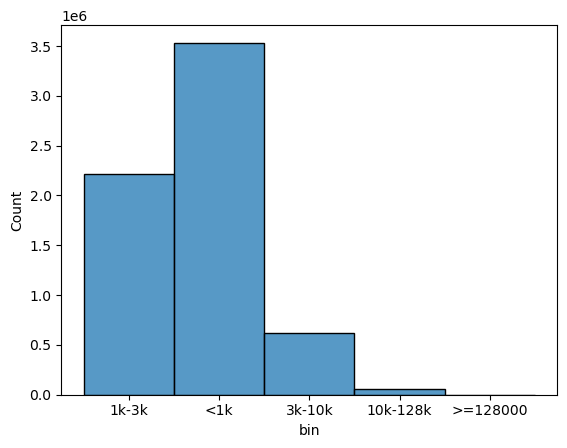

In [15]:
sns.histplot(data=swe_df, x="bin")

In [7]:
parts = []
for b, n in n_per_bin.items():
    g = swe_df[swe_df["bin"] == b]
    parts.append(g.sample(n=n, random_state=seed))

swe_sampled = pd.concat(parts)
swe_sampled = swe_sampled.sample(frac=1, random_state=seed).reset_index()

In [8]:
swe_sampled.to_json("../data/swe_Latn/swe_Latn_corpus_ids.jsonl", orient="records", lines=True, force_ascii=False)

In [10]:
swe_stats = swe_sampled.describe()
#fin_stats = fin_sampled.describe()

In [11]:
swe_stats.loc['total'] = {'tokens': swe_df['tokens'].sum(), 'chars': swe_df['chars'].sum()}
fin_stats.loc['total'] = {'tokens': fin_df['tokens'].sum(), 'chars': fin_df['chars'].sum()}

In [12]:
swe_stats.to_csv("../data/swe_Latn/swe_Latn_corpus_stats.csv")
fin_stats.to_csv("../data/fin_Latn/fin_Latn_corpus_stats.csv")

In [21]:
del fin_df, fin_d, swe_df, swe_d

# Sample documents for question creation

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
swe_sampled = pd.read_json("../data/swe_Latn/swe_Latn_corpus_ids.jsonl",orient="records",lines=True)
fin_sampled = pd.read_json("../data/fin_Latn/fin_Latn_corpus_ids.jsonl",orient="records",lines=True)

In [15]:
swe_train_df, swe_test_dev_df= train_test_split(swe_sampled, test_size=0.015, random_state=42,stratify=swe_sampled['bin'])
fin_train_df, fin_test_dev_df= train_test_split(fin_sampled, test_size=0.015, random_state=42,stratify=fin_sampled['bin'])

In [16]:
swe_test_dev_df['bin'].value_counts()

bin
10k-128k    750
3k-10k      674
1k-3k        75
>=128000      1
Name: count, dtype: int64

In [36]:
fin_test_dev_df['bin'].value_counts()

bin
10k-128k    750
3k-10k      674
1k-3k        75
>=128000      1
Name: count, dtype: int64

In [17]:
swe_test_dev_df.to_json("../data/swe_Latn/swe_Latn_test_dev_ids.jsonl", orient="records", lines=True, force_ascii=False)
fin_test_dev_df.to_json("../data/fin_Latn/fin_Latn_test_dev_ids.jsonl", orient="records", lines=True, force_ascii=False)